# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [14]:
# Import essential libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Importing tensor flow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Import sklearn libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


Load the dataset.

In [15]:
# Load and unzip the dataset
data_folder= 'data'
sub_folder = sorted(os.listdir(data_folder))
print('Classes found:', sub_folder)
print('Number of classes', len(sub_folder))



Classes found: ['.DS_Store', 'Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
Number of classes 8


There are basically 7 folders(ignoring .DS_Store), classified with respective name. Data is properly segregated and the folders are loaded successfully.

## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [16]:
# Create a function to load the raw images
def load_images(path):
    img = Image.open(path).convert('RGB')
    try:
        img.verify()
        return img
    except:
        return


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [32]:
# Get the images and their labels

#Create an array of images and labels and load from each sub directories
images =[]
labels =[]
categories =[]

for folder in sub_folder:
    complete_path = os.path.join(data_folder,folder)

    #There are some hidden files like .DS_Store is generated so we need to get rid of such files so that we are reading proper folders
    if not os.path.isdir(complete_path):
        continue

    #Creating array of categories which are actual directory and not files like .DS_Store
    categories.append(folder)
    for file in os.listdir(complete_path):
        file_complete_path = os.path.join(complete_path, file)
        image = load_images(file_complete_path)
        if image is not None:
            images.append(image)
            labels.append(folder)

#Convert both images and labels to numphy array for easy processing
images_np = np.array(images)
labels_np = np.array(labels)

print(f'Image array shape: {images_np.shape}')
print(f'Label array shape: {labels_np.shape}')




Image array shape: (7625, 256, 256, 3)
Label array shape: (7625,)


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

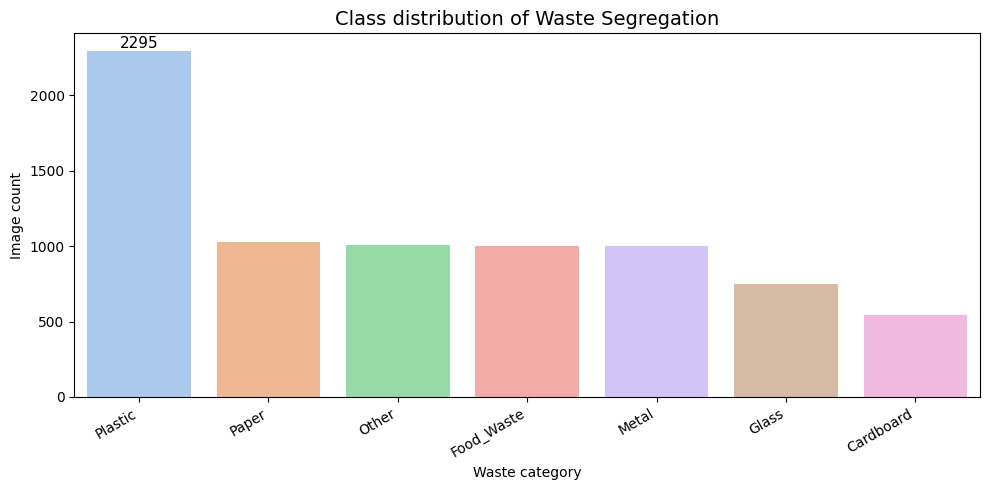

In [18]:
# Visualise Data Distribution
label_series = pd.Series(labels_np)
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x=label_series, ax=ax, order=label_series.value_counts().index, palette='pastel')
ax.set_title('Class distribution of Waste Segregation', fontsize=14)
ax.set_xlabel('Waste category')
ax.set_ylabel('Image count')
ax.bar_label(ax.containers[0], fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

7


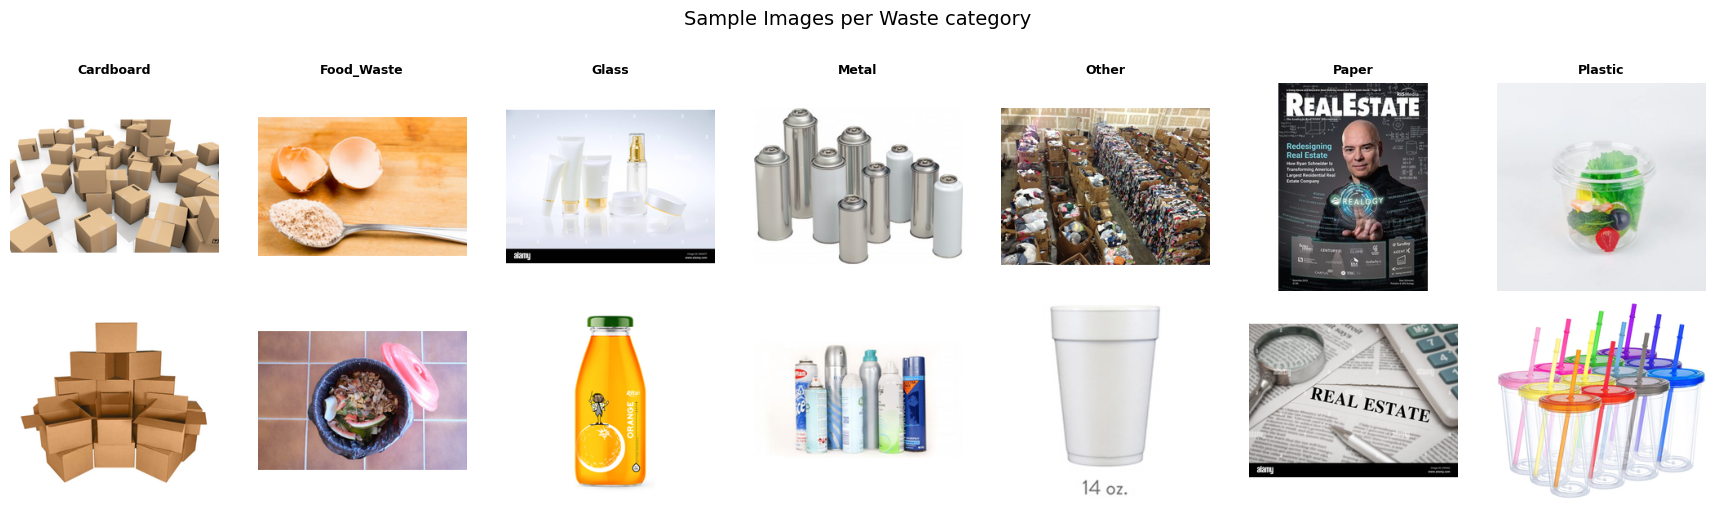

In [ ]:
# Visualise Sample Images (across different labels)
col_length = len(categories)
print(col_length)

#number of images per cateogry
samples = 2

fig, axes = plt.subplots(samples, col_length, figsize=(col_length * 2.5, samples * 2.5))
fig.suptitle('Sample Images per Waste category', fontsize =14, y=1.02)

for col, cat in enumerate(categories):
    cat_indeces = np.where(labels_np == cat)[0]
    sampled = np.random.choice(cat_indeces, size = samples, replace = False)
    for row, idx in enumerate(sampled):
        axes[row, col].imshow(images[idx])
        axes[row, col].axis('off')
        if row ==0:
            axes[row, col].set_title(cat, fontsize=9, fontweight ='bold')


plt.tight_layout()
plt.show()



#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [ ]:
# Find the smallest and largest image dimensions from the data set
raw_sizes = []
for cls in sub_folder:
    cls_dir = os.path.join(data_folder, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            with Image.open(fpath) as img:
                raw_sizes.append(img.size)   # (width, height)
        except Exception:
            pass

widths  = [s[0] for s in raw_sizes]
heights = [s[1] for s in raw_sizes]

print(f'Width  — min: {min(widths)}, max: {max(widths)}')
print(f'Height — min: {min(heights)}, max: {max(heights)}')



Width  — min: 256, max: 256
Height — min: 256, max: 256
All images are already uniform 256×256 px in this dataset.


All Images are of sane size with dimension 256x256

In [33]:
# Resize the image dimensions
IMG_SIZE = (128, 128)

images_rs = np.array(
    [np.array(img.resize(IMG_SIZE), dtype='float32') / 255.0
     for img in images],
    dtype='float32'
)

print(f'Resized array shape: {images_rs.shape}')


Resized array shape: (7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [37]:
# Encode the labels suitably
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_np)   # shape (N,), dtype int

# One-hot encode for categorical cross-entropy loss
num_classes = len(le.classes_)
labels_onehot = tf.keras.utils.to_categorical(labels_encoded, num_classes=num_classes)

print('Class mapping:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx} -> {cls}')
print(f'\nlabels_encoded shape : {labels_encoded.shape}')
print(f'labels_onehot  shape : {labels_onehot.shape}')


Class mapping:
  0 -> Cardboard
  1 -> Food_Waste
  2 -> Glass
  3 -> Metal
  4 -> Other
  5 -> Paper
  6 -> Plastic

labels_encoded shape : (7625,)
labels_onehot  shape : (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [40]:
# Assign specified parts of the dataset to train and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(
    images_rs, labels_onehot,
    test_size=0.30,
    random_state=42,
    stratify=labels_encoded
)

# further split temp into val and test (50/50 → each 15% of total)
labels_temp_int = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=labels_temp_int
)

print(f'Training dataset : {X_train.shape[0]}  labels: {y_train.shape[0]}')
print(f'Validation dataset : {X_val.shape}  labels: {y_val.shape}')
print(f'Testing daaset : {X_test.shape}  labels: {y_test.shape}')


Training dataset : 5337  labels: 5337
Validation dataset : (1144, 128, 128, 3)  labels: (1144, 7)
Testing daaset : (1144, 128, 128, 3)  labels: (1144, 7)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
# Build and compile the model
# Build and compile the model

def build_cnn(input_shape=(128, 128, 3), num_classes=7, dropout_rate=0.4):

    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate / 2),

        # ── Block 2 ──────────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate / 2),

        # ── Block 3 ──────────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate / 2),

        # ── Fully Connected Head ──────────────────────────────
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        layers.Dense(num_classes, activation='softmax')
    ], name='WasteSegregationCNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=num_classes)
model.summary()


Model: "WasteSegregationCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,831 (32.37 MB)

 Trainable params: 8,484,871 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Epoch 1/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 301ms/step - accuracy: 0.3813 - loss: 1.7658 - val_accuracy: 0.2159 - val_loss: 2.2930 - learning_rate: 0.0010
Epoch 2/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 302ms/step - accuracy: 0.4838 - loss: 1.3966 - val_accuracy: 0.3138 - val_loss: 2.2591 - learning_rate: 0.0010
Epoch 3/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 291ms/step - accuracy: 0.5786 - loss: 1.1773 - val_accuracy: 0.3313 - val_loss: 2.1633 - learning_rate: 0.0010
Epoch 4/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 295ms/step - accuracy: 0.6324 - loss: 1.0206 - val_accuracy: 0.3820 - val_loss: 1.6526 - learning_rate: 0.0010
Epoch 5/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 285ms/step - accuracy: 0.7062 - loss: 0.8319 - val_accuracy: 0.3601 - val_loss: 1.8309 - learning_rate: 0.0010
Epoch 6/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 304ms/step - accuracy: 0.7690 - loss: 0.6721 - val_accuracy: 0.4292 - val_loss: 1.5676 - learning_rate: 0.0010
Epoch 7/40
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 297ms/step - accuracy: 0.8130 - loss: 0.

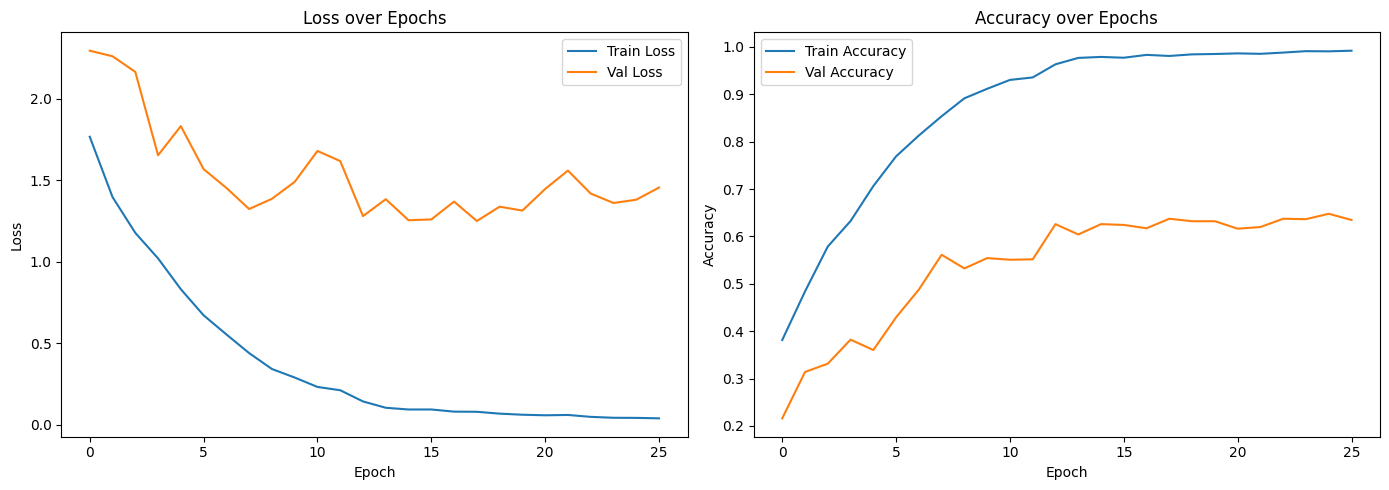

In [42]:
# Training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Loss     : 1.3597
Test Accuracy : 0.6337 (63.37%)
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.68      0.77      0.72        81
  Food_Waste       0.69      0.77      0.73       150
       Glass       0.60      0.51      0.56       113
       Metal       0.64      0.60      0.62       150
       Other       0.49      0.62      0.54       151
       Paper       0.52      0.48      0.50       155
     Plastic       0.74      0.67      0.70       344

    accuracy                           0.63      1144
   macro avg       0.62      0.63      0.62      1144
weighted avg       0.64      0.63      0.63      1144



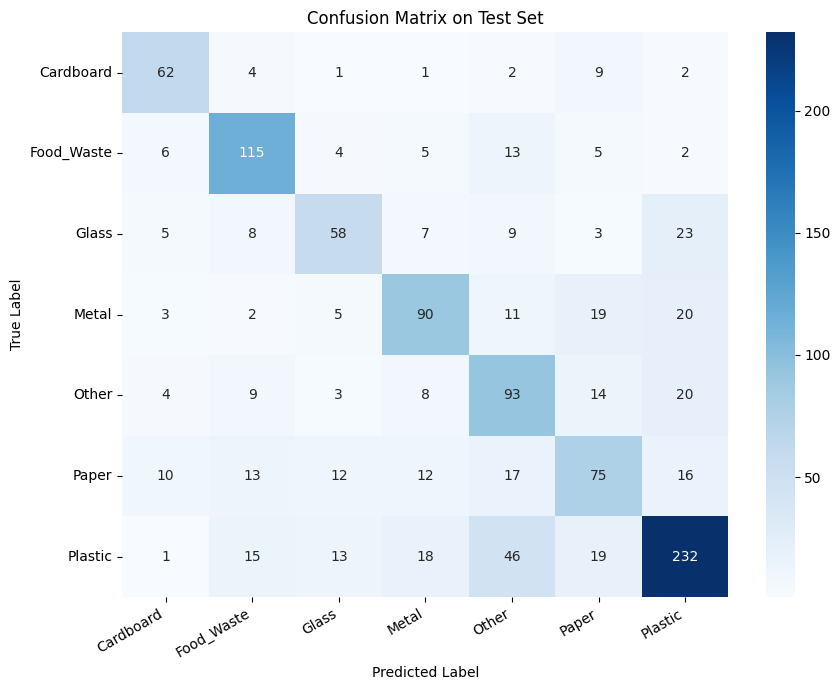

In [43]:
# Evaluate on the test set; display suitable metrics
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

# Data Summary
| Category | Count |
|----------|-------|
| Cardboard | 540 |
| Food_Waste | 1000 |
| Glass | 750 |
| Metal | 1000 |
| Other | 1010 |
| Paper | 1030 |
| Plastic | 2295 |

- Total number of images: 7625
- More number of images are from plastic category
- Less number of images are from cardboard category
- All images are of same resolution which is 256x256


# Model Summary
The CNN contains:
- 3 Convolutional blocks(32/64/128)
- Batch Normalization layers
- Max Pooling layers
- Dropout regularization
- Test accuracy : 63.37%
- Good performance on:
    - Plastic
    - Food waste
    - Cardboard
- Bad performance on:
    - Other
    - Paper
    - Glass
